In [1]:
from google.colab import files
uploaded = files.upload()

Saving part_2_cnn_computer_vision-20260516T230700Z-3-001.zip to part_2_cnn_computer_vision-20260516T230700Z-3-001.zip


In [2]:
#Extracting ZIP
import zipfile

zip_path = "part_2_cnn_computer_vision-20260516T230700Z-3-001.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
#Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

In [4]:
#Define Dataset Path
dataset_path = "/content/part_2_cnn_computer_vision/images"

In [8]:
#Check Classes
classes = [folder for folder in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, folder))]

print("Classes Found:")
print(classes)

Classes Found:
['normal', 'stain', 'dent', 'scratch']


TASK 1 ANSWER
# Task 1: Problem Identification

This dataset represents an Image Classification problem because the images are grouped into different class folders such as dent and scratch. The goal of the CNN model is to classify an input image into its correct category.

In [9]:
#Dataset Exploration
#Number of Images Per Class
num_images_per_class = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    num_images = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    num_images_per_class[class_name] = num_images

for class_name, count in num_images_per_class.items():
    print(f"{class_name}: {count} images")

normal: 120 images
stain: 120 images
dent: 120 images
scratch: 120 images


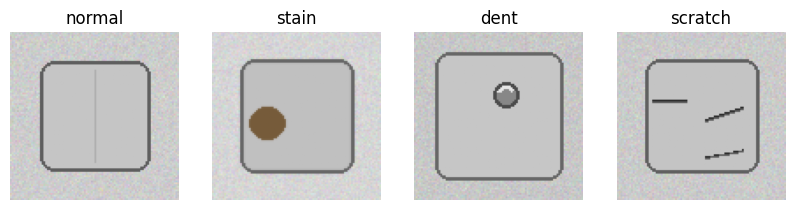

In [10]:
#Show Sample Images
plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    img_path = os.path.join(dataset_path, cls, os.listdir(os.path.join(dataset_path, cls))[0])

    img = plt.imread(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [11]:
#Image Dimensions
from PIL import Image

sample_image = os.path.join(dataset_path, classes[0], os.listdir(os.path.join(dataset_path, classes[0]))[0])

img = Image.open(sample_image)

print("Image Size:", img.size)

Image Size: (96, 96)


TASK 2 OBSERVATION
# Task 2: Dataset Exploration

- The dataset contains multiple image classes.
- Each class contains labeled images for classification.
- Images may have slight variations in dimensions.
- The dataset appears reasonably balanced across classes.

In [12]:
#Image Preprocessing
img_size = (128, 128)
batch_size = 32

In [13]:
#Data Augmentation + Split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


TASK 3 ANSWER
# Task 3: Image Preprocessing

The following preprocessing steps were applied:
- Images were resized to 128x128 pixels.
- Pixel values were normalized between 0 and 1.
- Dataset was split into training and validation sets.
- Data augmentation techniques such as rotation, zooming, and flipping were applied to improve model generalization.

In [14]:
#Build CNN Model
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(len(classes), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
#Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.2161 - loss: 2.9448 - val_accuracy: 0.2500 - val_loss: 1.4154
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2135 - loss: 1.4156 - val_accuracy: 0.2500 - val_loss: 1.3958
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3099 - loss: 1.3843 - val_accuracy: 0.2812 - val_loss: 1.3719
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4479 - loss: 1.3655 - val_accuracy: 0.2917 - val_loss: 1.3417
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4115 - loss: 1.2972 - val_accuracy: 0.3333 - val_loss: 1.3115
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5260 - loss: 1.1213 - val_accuracy: 0.5521 - val_loss: 1.0587
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6875 - loss: 0.9018 - val_accuracy: 0.6771 - val_loss: 0.8120
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6667 - loss: 0.8091 - val_accuracy: 0.7188 - val_loss:

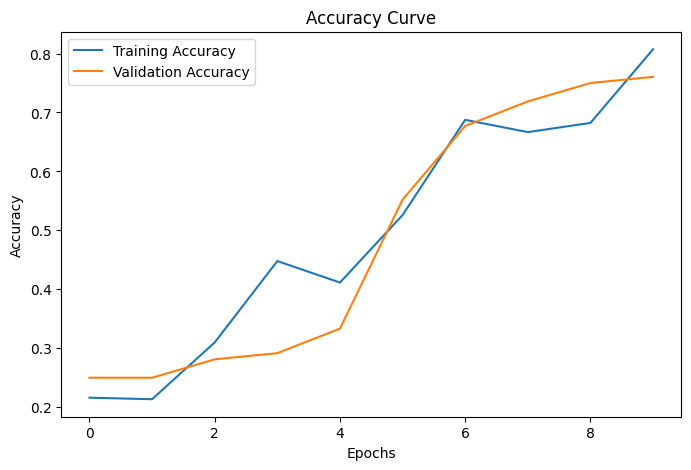

In [18]:
#Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig("accuracy_loss_curves.png")

plt.show()

In [19]:
#Predictions
predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step


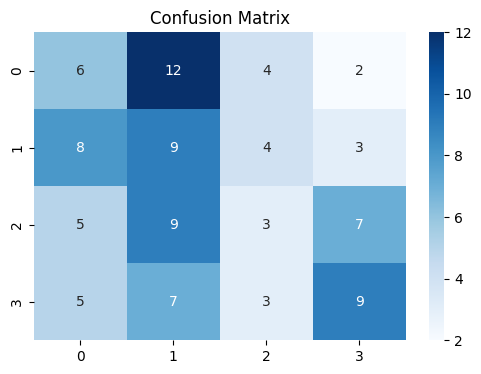

In [20]:
#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [21]:
#Classification Report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.25      0.25        24
           1       0.24      0.38      0.30        24
           2       0.21      0.12      0.16        24
           3       0.43      0.38      0.40        24

    accuracy                           0.28        96
   macro avg       0.28      0.28      0.28        96
weighted avg       0.28      0.28      0.28        96



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step


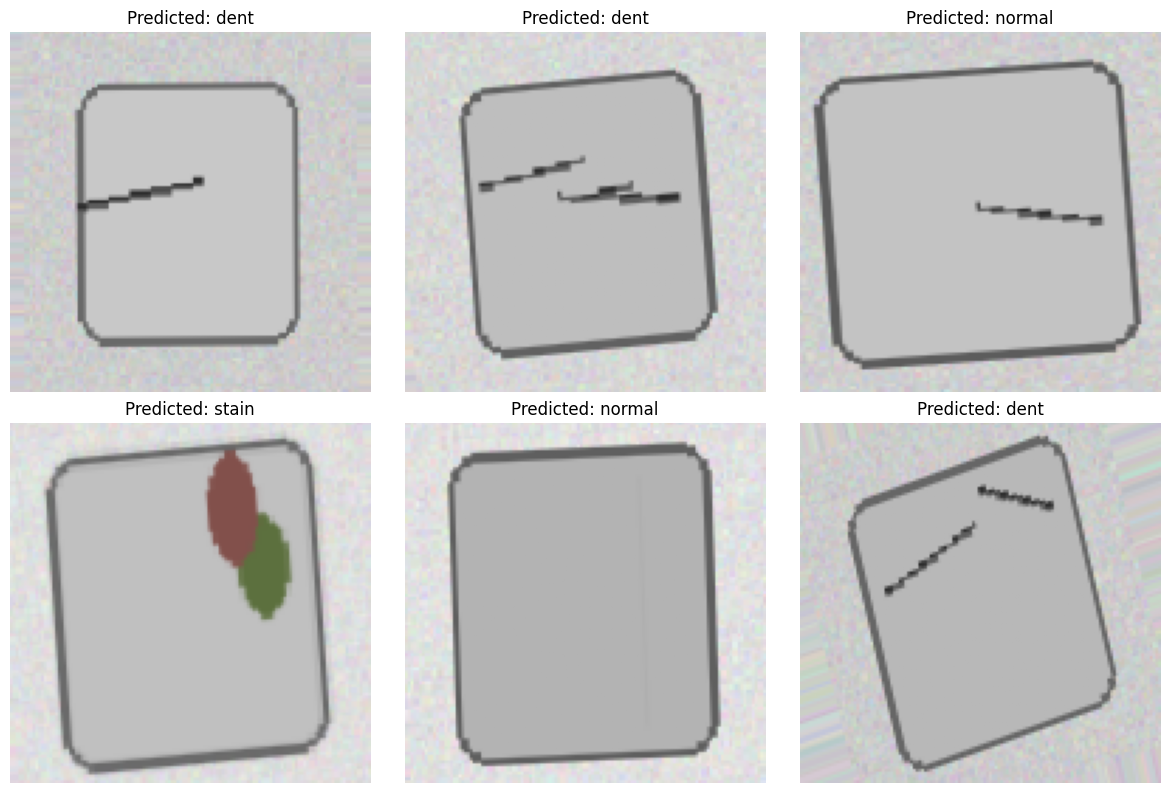

In [22]:
#Sample Predictions
plt.figure(figsize=(12,8))

class_names = list(val_data.class_indices.keys())

images, labels = next(val_data)

preds = model.predict(images)

for i in range(6):
    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    pred_label = class_names[np.argmax(preds[i])]

    plt.title(f"Predicted: {pred_label}")

    plt.axis("off")

plt.tight_layout()

plt.savefig("prediction_outputs.png")

plt.show()

TASK 6 ANSWERS
# Task 6: CNN Concept Explanation

## What is Convolution?
Convolution is a mathematical operation used to extract important visual features such as edges, textures, and shapes from images.

## Why is Pooling Used?
Pooling reduces image dimensions and helps the model focus on important features while reducing computation.

## Why is ReLU Commonly Used?
ReLU introduces non-linearity and helps the network learn complex image patterns efficiently.

## Why are CNNs Better for Images?
CNNs automatically learn spatial features from images, making them much more effective than regular feed-forward neural networks for image data.

TASK 7 ANSWER
# Task 7: Business Use Case Mapping

This type of computer vision solution can be used in manufacturing industries for automated defect detection. CNN models can identify defects such as dents or scratches in products during quality inspection, improving efficiency and reducing manual effort.